# heatmap plot from casim data

In [62]:
import xarray as xr 
import pandas as pd
import numpy as np 
from glob import glob 
import matplotlib.pyplot as plt 
from scipy.special import gamma, gammainc
import re
import xesmf as xe
import os
import imageio
from matplotlib.lines import Line2D


import sys
# needed so I can call the functions from another folder.
sys.path.append('/home/users/esree/shes_a_model/model_functions/')
# loads of homemade functions <3 <3
from casim_boring_functions import open_declan_nc, make_variable, slice_to_domain


In [2]:
a_date = '20220730'
a_experiment = 'expt1'

new_combined = open_declan_nc(a_date, a_experiment, max_time = None)
sliced_domain = slice_to_domain(new_combined)

## make new units for some hydrometeors
new_hydro_list = ['graupel', 'cloud', 'ice', 'snow', 'rain']
for hydro in new_hydro_list:
    sliced_domain = make_variable(sliced_domain, hydro)

for hydro in new_hydro_list:
    sliced_domain = make_variable(sliced_domain, hydro, 'mass')

/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:450: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 9.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (100, 100).
  result_vars[name] = func(*variable_args)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/array/routines.py:333: PerformanceWarning: Increasing number of chunks by factor of 20
  intermediate = blockwise(


## make gif of max value from domain

In [5]:
sliced_domain

<xarray.Dataset> Size: 167MB
Dimensions:                                           (time: 51,
                                                       model_level_number: 70,
                                                       grid_latitude: 22,
                                                       grid_longitude: 14)
Coordinates:
  * time                                              (time) datetime64[ns] 408B ...
  * model_level_number                                (model_level_number) int32 280B ...
  * grid_latitude                                     (grid_latitude) float32 88B ...
  * grid_longitude                                    (grid_longitude) float64 112B ...
    forecast_reference_time                           datetime64[ns] 8B ...
    forecast_period                                   timedelta64[ns] 8B ...
    level_height                                      (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    sigma                                             (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    lon                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    lat                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    true_level_height_asl                             (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(70, 22, 14), meta=np.ndarray>
Data variables: (12/38)
    number_of_cloud_droplets_per_kg_of_air            (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_rain_drops_per_kg_of_air                (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_ice_particles_per_kg_of_air             (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_snow_aggregates_per_kg_of_air           (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_graupel_particles_per_kg_of_air         (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    cloud_volume_fraction_in_atmosphere_layer         (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    ...                                                ...
    ice_mass_m3                                       (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    ice_mass_L                                        (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    snow_mass_m3                                      (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    snow_mass_L                                       (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    rain_mass_m3                                      (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    rain_mass_L                                       (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
Attributes: (12/14)
    um_suite:          u-dd455@281404
    casim_branches:    https://code.metoffice.gov.uk/trac/monc/browser/casim/...
    um_branches:       https://code.metoffice.gov.uk/trac/um/browser/main/br

### v1 of gif making

In [8]:
save_folder = '/home/users/esree/shes_a_model/dcmex_plotting/plot_saving/lat_lon_birdseye/'

delete_pngs = True

# make new folder if doesn't already exist
time_list = sliced_domain["time"].values
var_name = 'upward_air_velocity' #########################################################
var_units = 'm/s' #sliced_domain[var_name].units

specif_save_folder = f'{save_folder}{a_date}_{a_experiment}/{var_name}'
if not os.path.exists(specif_save_folder):
    os.makedirs(specif_save_folder)
saving_location = specif_save_folder+'/'

orography = sliced_domain["true_level_height_asl"].isel(model_level_number=0)

# then for each grid lat / lon, we choose the max height
max_height_lat = orography.max(dim="grid_latitude") # function of longitude
max_height_lon = orography.max(dim="grid_longitude") # fuction of latitude

## as lat and lon are 2D (bcos model grid lat lon is rotated)
## this is done to flatten out lat / lon dimensions
lon_1d = sliced_domain["lon"].mean(dim="grid_latitude") #(grid_longitude,)
lat_1d = sliced_domain["lat"].mean(dim="grid_longitude") #(grid_latitude,)

min_lat = 34.2
max_lat = 33.8
min_lon = -107.4
max_lon = -107.0

vmax_n = sliced_domain[var_name].max().values
vmin_n = sliced_domain[var_name].min().values
m_height_lim = 15000
colour_map = "coolwarm" #"Blues_r" 'coolwarm'


In [10]:
for t in time_list:
    a_time = sliced_domain.sel(time=t)
    save_name = f"{pd.to_datetime(str(t)).strftime('%y%m%d_%H%M%S')}_{var_name}"
    
    lat_max = a_time[var_name].max(dim="grid_latitude") # (model_level_number, grid_longitude)
    z_lat_max = a_time["true_level_height_asl"].max(dim="grid_latitude") # (model_level_number, grid_longitude)
    lon_max = a_time[var_name].max(dim="grid_longitude") # (model_level_number, grid_latitude)
    z_lon_max = a_time["true_level_height_asl"].max(dim="grid_longitude") # (model_level_number, grid_latitude)
    z_max = a_time[var_name].max(dim="model_level_number") # (grid_latitude, grid_longitude)

    z = lat_max.values 
    h = z_lat_max.values 
    lon = lon_1d.values

    """ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ plotting ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ """
    fig = plt.figure(figsize=(10, 8))

    # Create a 3x3 logical grid
    gs = fig.add_gridspec(3, 3)

    # Subplots with custom spans:
    ax1 = fig.add_subplot(gs[0, 0:2])   # top-left → 2 cols × 1 row
    ax2 = fig.add_subplot(gs[0, 2])     # top-right → 1 col × 1 row
    ax2.axis("off")
    ax3 = fig.add_subplot(gs[1:3, 0:2]) # bottom-left → 2 cols × 2 rows
    ax4 = fig.add_subplot(gs[1:3, 2])   # bottom-right → 1 col × 2 rows

    ax1.plot(lon_1d, max_height_lat, color="grey")
    ax1.set_xlim(min_lon, max_lon)

    # the pcm -> for making colourbar
    ax1.pcolormesh(
        lon_1d.values,
        z_lat_max.values,
        lat_max.values,
        shading="auto",
        cmap=colour_map,
        vmin=vmin_n, vmax=vmax_n)
    ax1.set_ylabel("alt (m)")
    ax1.set_ylim(0, m_height_lim)
    ax1.tick_params(axis="x", bottom=False, labelbottom=False) # turn off y-axis ticks and labels for ax4

    ax4.plot(max_height_lon, lat_1d, color="grey")
    ax4.set_ylim(max_lat, min_lat)
    ax4.pcolormesh(
        z_lon_max.T,
        lat_1d,
        lon_max.T,
        shading="auto",
        cmap=colour_map,
        vmin=vmin_n, vmax=vmax_n)
    ax4.set_xlabel("alt (m)")
    ax4.set_xlim(0, m_height_lim)
    ax4.tick_params(axis="y", left=False, labelleft=False) # turn off y-axis ticks and labels for ax4

    ax3.set_xlim(min_lon, max_lon)
    ax3.set_ylim(max_lat, min_lat)

    ax3.contour(
        sliced_domain["lon"].values,
        sliced_domain["lat"].values,
        orography.values,
        levels=[2250],   # only this contour
        colors="grey",
        linewidths=2)

    pcm = ax3.pcolormesh(
        a_time["lon"].values,
        a_time["lat"].values,
        z_max.values,
        shading="auto",
        cmap=colour_map,
        vmin=vmin_n, vmax=vmax_n)

    ax3.set_xlabel("Longitude")
    ax3.set_ylabel("Latitude")

    ### add colourbar

    cbar = fig.colorbar(
        pcm,
        ax=[ax1, ax3, ax4],
        orientation="vertical",
        location="left",
        pad=-0.0001,
        fraction=0.03)
    cbar.set_label(f"max {var_name} ({var_units})")

    ## set time 
    time_name = pd.to_datetime(str(t)).strftime("%H:%M:%S")
    title_str = f'{var_name} \n {time_name} UTC'

    ax2.set_title(title_str, loc="center", y=0.5, fontsize=16)

    plt.tight_layout()
    plt.savefig(saving_location+save_name, bbox_inches='tight')
    plt.close()

## make gif
image_list = glob(os.path.join(saving_location, '*.png'))
image_list.sort()
frames = []
for i in range(len(image_list)):
    image = imageio.v2.imread(image_list[i])
    frames.append(image)

imageio.mimsave(saving_location+f'{a_date}_{a_experiment}_{var_name}.gif', frames, fps=5)
if delete_pngs:
    for image in image_list:
        os.remove(image)


/tmp/ipykernel_2157259/3909055052.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2157259/3909055052.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2157259/3909055052.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2157259/3909055052.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2157259/3909055052.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2157259/3909055052.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so

## w contour in plots
where are highest updrafts?
<br>
plotting w and graupel conc? somehow together
<br>
melting level? / alt?

In [4]:
t ='2022-07-30T18:00:00.000000000'
a_time = sliced_domain.sel(time=t)
a_time


<xarray.Dataset> Size: 3MB
Dimensions:                                           (model_level_number: 70,
                                                       grid_latitude: 22,
                                                       grid_longitude: 14)
Coordinates:
  * model_level_number                                (model_level_number) int32 280B ...
  * grid_latitude                                     (grid_latitude) float32 88B ...
  * grid_longitude                                    (grid_longitude) float64 112B ...
    time                                              datetime64[ns] 8B 2022-...
    forecast_reference_time                           datetime64[ns] 8B ...
    forecast_period                                   timedelta64[ns] 8B ...
    level_height                                      (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    sigma                                             (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    lon                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    lat                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    true_level_height_asl                             (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(70, 22, 14), meta=np.ndarray>
Data variables: (12/38)
    number_of_cloud_droplets_per_kg_of_air            (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    number_of_rain_drops_per_kg_of_air                (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    number_of_ice_particles_per_kg_of_air             (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    number_of_snow_aggregates_per_kg_of_air           (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    number_of_graupel_particles_per_kg_of_air         (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    cloud_volume_fraction_in_atmosphere_layer         (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    ...                                                ...
    ice_mass_m3                                       (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    ice_mass_L                                        (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    snow_mass_m3                                      (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    snow_mass_L                                       (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    rain_mass_m3                                      (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
    rain_mass_L                                       (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(35, 11, 5), meta=np.ndarray>
Attributes: (12/14)
    um_suite:          u-dd455@281404
    casim_branches:    https://code.metoffice.gov.uk/trac/monc/browser/casim/...
    um_branches:       https://code.metoffice.gov.uk/trac/um/browser/main/bra...
    creator_contact:   Declan Finney (d.l.finney@leeds.ac.uk), University of ...
    title:             Simulations over the southwest USA for the DCMEX campa...


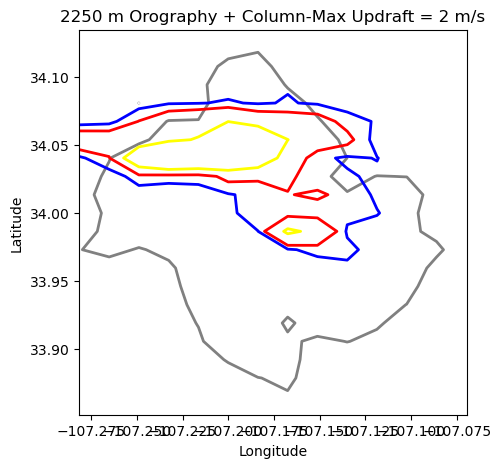

In [6]:
fig = plt.figure(figsize=(5, 5))
ax1 = fig.add_subplot(111)   # top-left → 2 cols × 1 row
lon_1d = a_time["lon"].mean(dim="grid_latitude") #(grid_longitude,)
lat_1d = a_time["lat"].mean(dim="grid_longitude") #(grid_latitude,)

orography = a_time["true_level_height_asl"].isel(model_level_number=0)
max_height_lat = orography.max(dim="grid_latitude") # function of longitude
max_height_lon = orography.max(dim="grid_longitude") # fuction of latitude

ax1.contour(
    sliced_domain["lon"].values,
    sliced_domain["lat"].values,
    orography.values,
    levels=[2250],   # only this contour
    colors="grey",
    linewidths=2)

updraft = a_time['upward_air_velocity']
w_max = updraft.max(dim="model_level_number")


# Add contour where updraft = 2 m/s
ax1.contour(
    w_max["lon"].values,
    w_max["lat"].values,
    w_max.values,
    levels=[2],
    colors="red",
    linewidths=2)

ax1.contour(
    w_max["lon"].values,
    w_max["lat"].values,
    w_max.values,
    levels=[1],
    colors="blue",
    linewidths=2,
)
ax1.contour(
    w_max["lon"].values,
    w_max["lat"].values,
    w_max.values,
    levels=[5],
    colors="yellow",
    linewidths=2,
)

ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.set_title("2250 m Orography + Column-Max Updraft = 2 m/s")
plt.show()

(0.0, 15000.0)

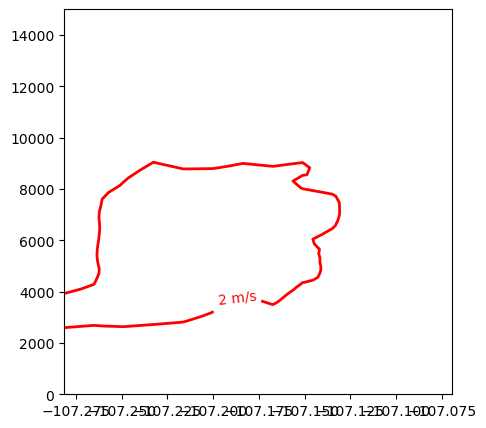

In [34]:
# Example: take max over latitude for each height/lon
w_cross = a_time["upward_air_velocity"].max(dim="grid_latitude")

# Corresponding height field
z_cross = a_time["true_level_height_asl"].max(dim="grid_latitude")

fig = plt.figure(figsize=(5, 5))
ax1 = fig.add_subplot(111)   # top-left → 2 cols × 1 row

# Make longitude 2D for contour()
X_lon = np.tile(
    lon_1d.values,
    (w_cross.shape[0], 1)
)

cs = ax1.contour(
    X_lon,
    z_cross.values,
    w_cross.values,
    levels=[2],
    colors="red",
    linewidths=2,
)

ax1.clabel(cs, fmt="2 m/s")
ax1.set_ylim(0, max_alt)

### v2 of gif making - with function!

In [71]:
def easy_plotting_lat_lon_map(a_time_step, 
                              variable_name = 'orography', 
                              colourmesh_contour = 'colourmesh',
                              contour_level = [2250],
                              a_vmax = None,
                              a_vmin = None,
                              max_alt = 15000,
                              specific_colourmap = None):
    ### this needs to be placed after the defined plot, just kind of slots into place
    ## can layer up plots

    """
    easy stacking plotting function for lat / lon maps, can overlay different things?

    Args:
        a_time_step (xarray dataset): a single time step of the model output, soelected using .sel(time=...)
        variable_name (str, optional): the variable you want to plot. Defaults to 'orography'.
        colourmesh_contour (str, optional): whether you want to plot the variable as a colourmesh or a contour. Defaults to 'colourmesh'.
        contour_level (list, optional): if plotting as a contour, the level(s) to plot. Defaults to [2250].
        vmax (float, optional): max value for colourmesh. Defaults to None.
        vmin (float, optional): min value for colourmesh. Defaults to None.
        var_units (str, optional): units of the variable being plotted, for colourbar labelling. Defaults to None.
        max_alt (int, optional): max altitude to plot. Defaults to 15000.
        specific_colourmap (str, optional): colourmap to use for colourmesh. Defaults to None, which will use the default colourmap.
    """

    min_lat = 34.2
    max_lat = 33.8
    min_lon = -107.4
    max_lon = -107.0

    # then for each grid lat / lon, we choose the max height
    lon_1d = a_time_step["lon"].mean(dim="grid_latitude") #(grid_longitude,)
    lat_1d = a_time_step["lat"].mean(dim="grid_longitude") #(grid_latitude,)

    if variable_name == 'orography':
        orography = a_time_step["true_level_height_asl"].isel(model_level_number=0)
        max_height_lat = orography.max(dim="grid_latitude") # function of longitude
        max_height_lon = orography.max(dim="grid_longitude") # fuction of latitude
        ax1.plot(lon_1d, max_height_lat, color="grey")
        ax4.plot(max_height_lon, lat_1d, color="grey")
        ax3.contour(
            a_time_step["lon"].values,
            a_time_step["lat"].values,
            orography.values,
            levels=contour_level,   # only this level
            colors="grey",
            linewidths=2)
    
    elif variable_name != 'orography': 
        lat_max = a_time_step[variable_name].max(dim="grid_latitude") # (model_level_number, grid_longitude)
        z_lat_max = a_time_step["true_level_height_asl"].max(dim="grid_latitude") # (model_level_number, grid_longitude)
        lon_max = a_time_step[variable_name].max(dim="grid_longitude") # (model_level_number, grid_latitude)
        z_lon_max = a_time_step["true_level_height_asl"].max(dim="grid_longitude") # (model_level_number, grid_latitude)
        z_max = a_time_step[variable_name].max(dim="model_level_number") # (grid_latitude, grid_longitude)
        
        lon_2d = np.tile(lon_1d.values,(lat_max.shape[0], 1))
        lat_2d = np.tile(lat_1d.values,(lon_max.shape[0], 1)).T

        if variable_name == 'upward_air_velocity':
            var_units = 'm/s'
        else:
            var_units = a_time_step[variable_name].units

        
        if colourmesh_contour == 'colourmesh':
            if specific_colourmap is None:
                specific_colourmap = ['Blues_r']

            ax1.pcolormesh(
                lon_1d.values,
                z_lat_max.values,
                lat_max.values,
                shading="auto",
                cmap=specific_colourmap[0],
                vmin=a_vmin, vmax=a_vmax)
            
            pcm = ax3.pcolormesh(
                a_time_step["lon"].values,
                a_time_step["lat"].values,
                z_max.values,
                shading="auto",
                cmap=specific_colourmap[0],
                vmin=a_vmin, vmax=a_vmax)
            
            ax4.pcolormesh(
                z_lon_max.T,
                lat_1d,
                lon_max.T,
                shading="auto",
                cmap=specific_colourmap[0],
                vmin=a_vmin, vmax=a_vmax)
            
            cbar = fig.colorbar(
                pcm,
                ax=[ax1, ax3, ax4],
                orientation="vertical",
                location="left",
                pad=-0.0001,
                fraction=0.03)

            cbar.set_label(f"max {variable_name} ({var_units})")

        
        elif colourmesh_contour != 'colourmesh':
            number_of_contours = len(contour_level)
            # contour plot
            if specific_colourmap is None or len(specific_colourmap) < number_of_contours:
                specific_colourmap = ['red', 'yellow', 'blue', 'green', 'orange']
            legend_lines = []

            for i in range(len(contour_level)):
                a_contour_level = contour_level[i]
                a_colour = specific_colourmap[i]
            
                ax1.contour(
                    lon_2d,
                    z_lat_max.values,
                    lat_max.values,
                    levels=[a_contour_level],
                    colors=a_colour,
                    linewidths=2,)

                # so get ledgend
                ax3.contour(
                    z_max["lon"].values,
                    z_max["lat"].values,
                    z_max.values,
                    levels=[a_contour_level],
                    colors=a_colour,
                    linewidths=2)
            
                ax4.contour(
                    z_lon_max.T,
                    lat_2d,
                    lon_max.T,
                    levels=[a_contour_level],
                    colors=a_colour,
                    linewidths=2)
            
                legend_lines.append(Line2D(
                    [0], [0],
                    color=a_colour,
                    lw=2,
                    label=f"{variable_name} = {a_contour_level} {var_units}"))
            
            ax2.legend(handles=legend_lines, loc= "lower center")
            
    
    ax1.set_ylabel("alt (m)")
    ax1.set_ylim(0, max_alt)
    ax1.set_xlim(min_lon, max_lon)
    ax1.tick_params(axis="x", bottom=False, labelbottom=False) # turn off x-axis ticks and labels for ax1

    ax3.set_xlim(min_lon, max_lon)
    ax3.set_ylim(max_lat, min_lat)
    ax3.set_xlabel("Longitude")
    ax3.set_ylabel("Latitude")

    ax4.set_xlabel("alt (m)")
    ax4.set_xlim(0, max_alt)
    ax4.set_ylim(max_lat, min_lat)
    ax4.tick_params(axis="y", left=False, labelleft=False) # turn off y-axis ticks and labels for ax4


/tmp/ipykernel_2470833/1742204689.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


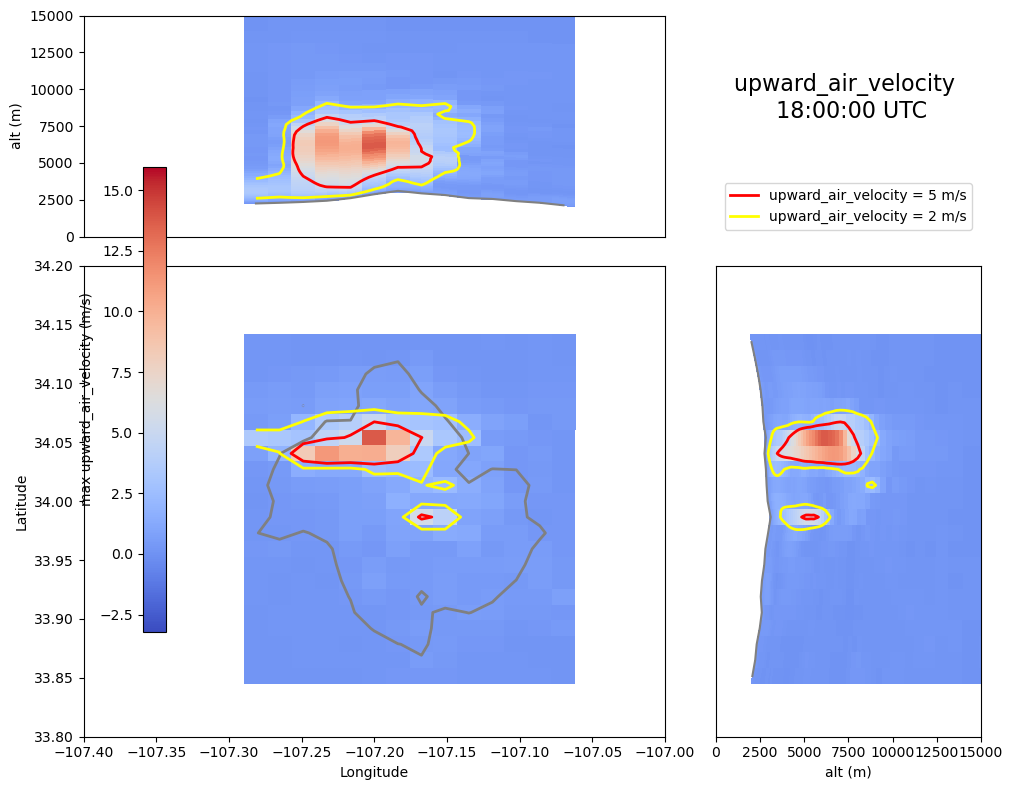

In [72]:
save_folder = '/home/users/esree/shes_a_model/dcmex_plotting/plot_saving/lat_lon_birdseye/'

delete_pngs = True

# make new folder if doesn't already exist
time_list = sliced_domain["time"].values
var_name = 'upward_air_velocity' #########################################################


vmax_n = sliced_domain[var_name].max().values
vmin_n = sliced_domain[var_name].min().values
m_height_lim = 15000
colour_map = "Blues_r" #"Blues_r" 'coolwarm'


a_time = sliced_domain.sel(time=t)
save_name = f"{pd.to_datetime(str(t)).strftime('%y%m%d_%H%M%S')}_{var_name}"

lat_max = a_time[var_name].max(dim="grid_latitude") # (model_level_number, grid_longitude)
z_lat_max = a_time["true_level_height_asl"].max(dim="grid_latitude") # (model_level_number, grid_longitude)
lon_max = a_time[var_name].max(dim="grid_longitude") # (model_level_number, grid_latitude)
z_lon_max = a_time["true_level_height_asl"].max(dim="grid_longitude") # (model_level_number, grid_latitude)
z_max = a_time[var_name].max(dim="model_level_number") # (grid_latitude, grid_longitude)

z = lat_max.values 
h = z_lat_max.values 
lon = lon_1d.values

""" ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ plotting ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ """
fig = plt.figure(figsize=(10, 8))

# Create a 3x3 logical grid
gs = fig.add_gridspec(3, 3)

# Subplots with custom spans:
ax1 = fig.add_subplot(gs[0, 0:2])   # top-left → 2 cols × 1 row
ax2 = fig.add_subplot(gs[0, 2])     # top-right → 1 col × 1 row
ax2.axis("off")
ax3 = fig.add_subplot(gs[1:3, 0:2]) # bottom-left → 2 cols × 2 rows
ax4 = fig.add_subplot(gs[1:3, 2])   # bottom-right → 1 col × 2 rows

easy_plotting_lat_lon_map(a_time)
easy_plotting_lat_lon_map(a_time, variable_name=var_name, a_vmin=vmin_n, a_vmax=vmax_n, specific_colourmap=['coolwarm'])
easy_plotting_lat_lon_map(a_time, variable_name=var_name, colourmesh_contour='contour', contour_level= [5, 2] , specific_colourmap=['red', 'yellow'])

## set time 
time_name = pd.to_datetime(str(t)).strftime("%H:%M:%S")
title_str = f'{var_name} \n {time_name} UTC'

ax2.set_title(title_str, loc="center", y=0.5, fontsize=16)

plt.tight_layout()





### blerg scatter

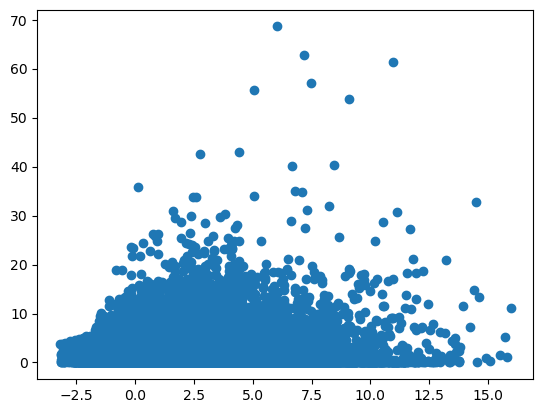

In [14]:
plt.scatter(sliced_domain['upward_air_velocity'], sliced_domain['graupel_number_L'])

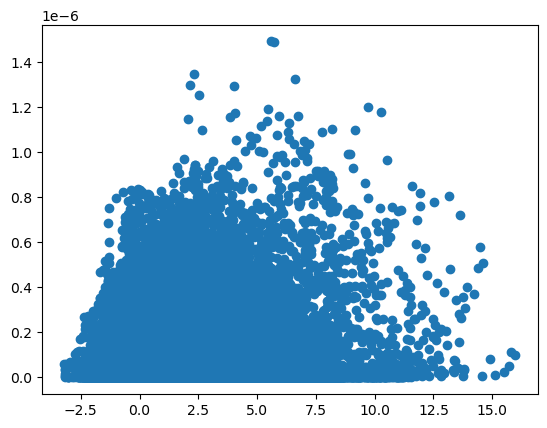

In [15]:
#plt.scatter(a_time['upward_air_velocity'], a_time['graupel_number_L'])

plt.scatter(sliced_domain['upward_air_velocity'], sliced_domain['graupel_mass_L'])

Text(0, 0.5, 'graupel mass conc (kg/L)')

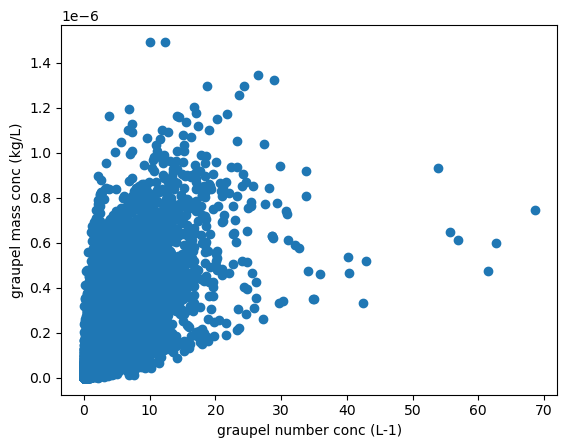

In [16]:
plt.scatter(sliced_domain['graupel_number_L'], sliced_domain['graupel_mass_L'])
plt.xlabel('graupel number conc (L-1)')
plt.ylabel('graupel mass conc (kg/L)')